# Image Classification EMNIST Letters
## HOG + SVM

Midterm Project - Computer Vision RE604  
## RIDHO AMANTA SILABAN 4222301091


---
## 0. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

from skimage.feature import hog
from skimage import exposure

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    LeaveOneOut, cross_val_predict,
    GridSearchCV, StratifiedKFold,
    train_test_split, cross_val_score
)
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    classification_report
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('  DONE IMPORT')


  DONE IMPORT


---
## 1. Dataset Preparation

In [ ]:
LETTERS_CSV = 'emnist-letters-train.csv'

print('Loading EMNIST Letters dataset...')
df = pd.read_csv(LETTERS_CSV, header=None)

print(f'  Dataset shape : {df.shape}')
print(f'  Columns       : col 0 = label, col 1-784 = pixels')

# Labels: 1–26 (A–Z)
labels_raw = df.iloc[:, 0].values
pixels_raw = df.iloc[:, 1:].values

print(f'  Unique labels : {sorted(np.unique(labels_raw))}')
print(f'  Total samples : {len(labels_raw)}')
print(f'  Pixel range   : {pixels_raw.min()} – {pixels_raw.max()}')

# Remap labels 1–26 → 0–25 (A–Z)
y_raw = labels_raw - 1
X_raw = pixels_raw
print(f'\n  Labels remapped: 1–26  →  0–25  (A=0, B=1, ..., Z=25)')

Loading EMNIST Letters dataset...
  Dataset shape : (88800, 785)
  Columns       : col 0 = label, col 1-784 = pixels
  Unique labels : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26)]
  Total samples : 88800
  Pixel range   : 0 – 255

  Labels remapped: 1–26  →  0–25  (A=0, B=1, ..., Z=25)


In [ ]:
# 1.2  Sample 100 per class (2600 total) + Shuffle
N_PER_CLASS = 100
N_CLASSES   = 26
N_TOTAL     = N_PER_CLASS * N_CLASSES   # 2600
LABEL_NAMES = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')

sampled_X, sampled_y = [], []
for cls in range(N_CLASSES):
    idx = np.where(y_raw == cls)[0]
    chosen = np.random.choice(idx, size=N_PER_CLASS, replace=False)
    sampled_X.append(X_raw[chosen])
    sampled_y.append(y_raw[chosen])

X_sampled = np.vstack(sampled_X)
y_sampled = np.concatenate(sampled_y)

# ── SHUFFLE before processing ──
shuffle_idx = np.random.permutation(N_TOTAL)
X_sampled   = X_sampled[shuffle_idx]
y_sampled   = y_sampled[shuffle_idx]

# Verify balance
_, counts = np.unique(y_sampled, return_counts=True)
assert all(counts == N_PER_CLASS), 'Class imbalance!'

print('=' * 50)
print('  Dataset Preparation Summary')
print('=' * 50)
print(f'  Source file      : {LETTERS_CSV}')
print(f'  Total samples    : {N_TOTAL}')
print(f'  Samples / class  : {N_PER_CLASS}')
print(f'  Number of classes: {N_CLASSES}  (A–Z)')
print(f'  Image size       : 28 x 28  (784 pixels)')
print(f'  Shuffled         : YES  (seed={RANDOM_STATE})')
print(f'  Balance check    : PASSED ✓  ({N_PER_CLASS} per class)')

  Dataset Preparation Summary
  Source file      : emnist-letters-train.csv
  Total samples    : 2600
  Samples / class  : 100
  Number of classes: 26  (A–Z)
  Image size       : 28 x 28  (784 pixels)
  Shuffled         : YES  (seed=42)
  Balance check    : PASSED ✓  (100 per class)


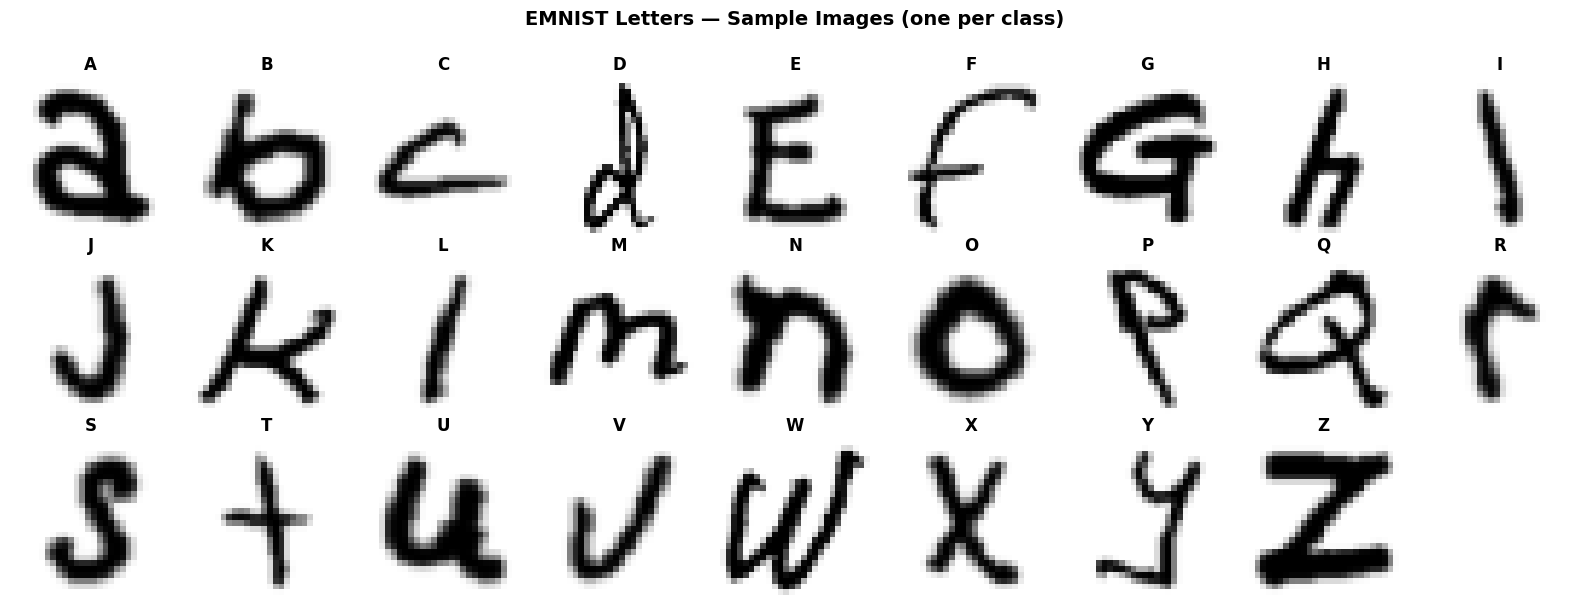

Saved: sample_images.png


In [ ]:
# ──────────────────────────────────────────────────────────
# 1.3  Visualize Sample Images (one per class)
# ──────────────────────────────────────────────────────────
def reshape_emnist(pixel_row):
    """EMNIST images are stored transposed → reshape + transpose."""
    return pixel_row.reshape(28, 28).T

fig, axes = plt.subplots(3, 9, figsize=(16, 6))
fig.suptitle('EMNIST Letters — Sample Images (one per class)',
             fontsize=14, fontweight='bold', y=1.01)

for i, ax in enumerate(axes.flat):
    if i >= N_CLASSES:
        ax.axis('off')
        continue
    idx = np.where(y_sampled == i)[0][0]
    img = reshape_emnist(X_sampled[idx])
    ax.imshow(img, cmap='gray_r')
    ax.set_title(LABEL_NAMES[i], fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: sample_images.png')

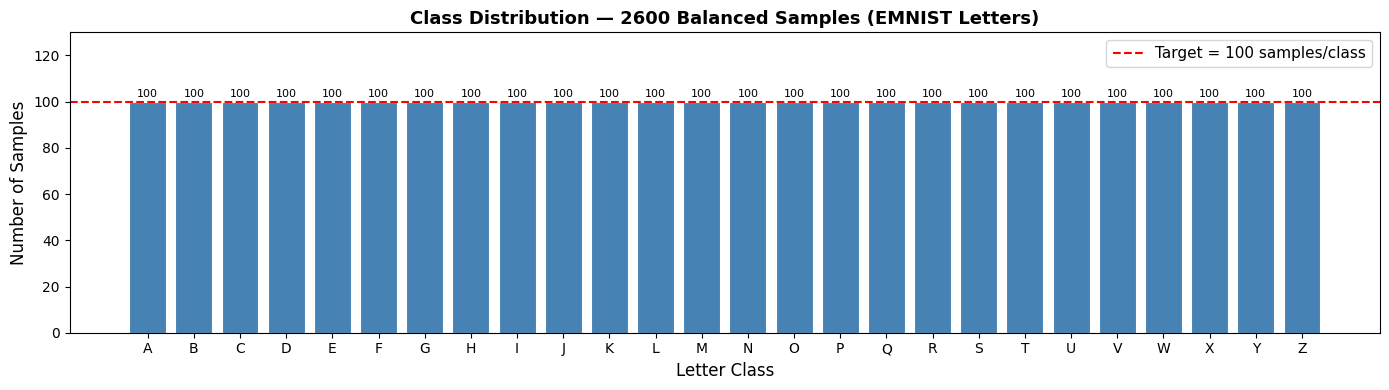

In [ ]:
# ──────────────────────────────────────────────────────────
# 1.4  Class Distribution Bar Chart
# ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(LABEL_NAMES, counts, color='steelblue', edgecolor='white', linewidth=0.8)
ax.axhline(N_PER_CLASS, color='red', linestyle='--', linewidth=1.5,
           label=f'Target = {N_PER_CLASS} samples/class')
ax.set_xlabel('Letter Class', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Class Distribution — 2600 Balanced Samples (EMNIST Letters)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 130)
ax.legend(fontsize=11)
for i, c in enumerate(counts):
    ax.text(i, c + 1, str(c), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ──────────────────────────────────────────────────────────
# 1.5  Train / Test Split  (80% / 20%) — Stratified
# ──────────────────────────────────────────────────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_sampled, y_sampled,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_sampled
)

_, tr_c = np.unique(y_train, return_counts=True)
_, te_c = np.unique(y_test,  return_counts=True)

print('=' * 50)
print('  Train / Test Split (Stratified)')
print('=' * 50)
print(f'  Training set : {len(y_train):4d} samples  (80%)')
print(f'  Test set     : {len(y_test):4d} samples  (20%)')
print(f'  Train/class  : {tr_c.min()}–{tr_c.max()}')
print(f'  Test/class   : {te_c.min()}–{te_c.max()}')


  Train / Test Split (Stratified)
  Training set : 2080 samples  (80%)
  Test set     :  520 samples  (20%)
  Train/class  : 80–80
  Test/class   : 20–20


---
## 2. HOG Feature Extraction

In [ ]:
def extract_hog(X_raw, orientations, pixels_per_cell,
                cells_per_block, transform_sqrt=True,
                block_norm='L2-Hys'):
    """Extract HOG features from raw pixel array (N, 784)."""
    feats = []
    for row in X_raw:
        img = reshape_emnist(row).astype(np.float64) / 255.0
        fd  = hog(img,
                  orientations=orientations,
                  pixels_per_cell=pixels_per_cell,
                  cells_per_block=cells_per_block,
                  transform_sqrt=transform_sqrt,
                  block_norm=block_norm,
                  feature_vector=True)
        feats.append(fd)
    return np.array(feats)

print('HOG extraction func.')

HOG extraction func.


In [ ]:
# 2.1  Extract HOG with Best Parameters
BEST_HOG = {
    'orientations'    : 9,
    'pixels_per_cell' : (4, 4),
    'cells_per_block' : (3, 3),
    'transform_sqrt'  : True,
    'block_norm'      : 'L2-Hys'
}

print('Extracting HOG features with best parameters:')
for k, v in BEST_HOG.items():
    print(f'  {k:<20}: {v}')

t0 = time.time()
X_train_hog = extract_hog(X_train_raw, **BEST_HOG)
X_test_hog  = extract_hog(X_test_raw,  **BEST_HOG)
print(f'\nExtraction done in {time.time()-t0:.1f}s')
print(f'  Train HOG shape : {X_train_hog.shape}')
print(f'  Test  HOG shape : {X_test_hog.shape}')
print(f'  Feature dim     : {X_train_hog.shape[1]} per image')

Extracting HOG features with best parameters:
  orientations        : 9
  pixels_per_cell     : (4, 4)
  cells_per_block     : (3, 3)
  transform_sqrt      : True
  block_norm          : L2-Hys

Extraction done in 6.7s
  Train HOG shape : (2080, 2025)
  Test  HOG shape : (520, 2025)
  Feature dim     : 2025 per image


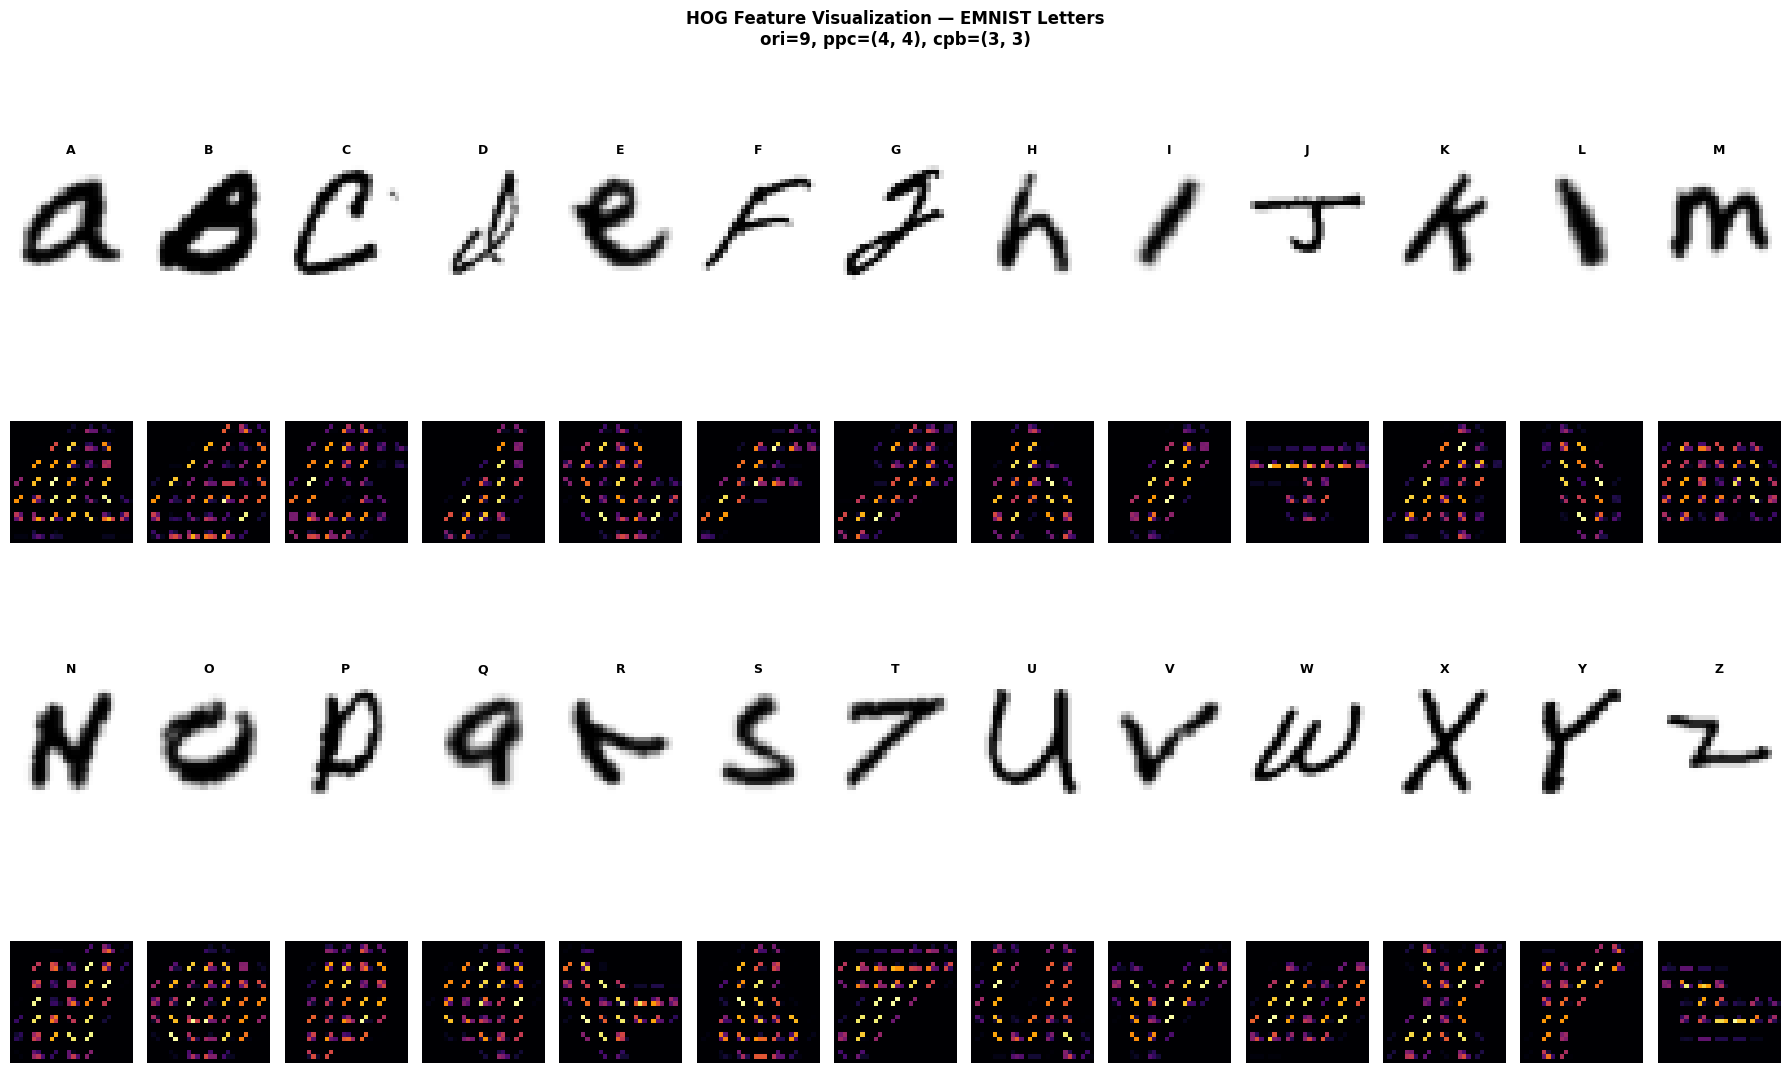

Saved: hog_visualization.png


In [ ]:
# 2.2  HOG Visualization (one sample per class)
fig, axes = plt.subplots(4, 13, figsize=(18, 12))
fig.suptitle(
    f'HOG Feature Visualization — EMNIST Letters\n'
    f'ori={BEST_HOG["orientations"]}, ppc={BEST_HOG["pixels_per_cell"]}, '
    f'cpb={BEST_HOG["cells_per_block"]}',
    fontsize=12, fontweight='bold'
)

# Layout: row 0 = orig imgs (A-M), row 1 = HOG imgs (A-M)
#         row 2 = orig imgs (N-Z), row 3 = HOG imgs (N-Z)
for cls in range(N_CLASSES):
    half  = N_CLASSES // 2          # 13
    r_off = (cls // half) * 2       # 0 or 2
    col   = cls % half              # 0-12

    mask = np.where(y_train == cls)[0]
    sample_idx = mask[0]
    img = reshape_emnist(X_train_raw[sample_idx]).astype(np.float64) / 255.0

    _, hog_vis = hog(img,
                     orientations=BEST_HOG['orientations'],
                     pixels_per_cell=BEST_HOG['pixels_per_cell'],
                     cells_per_block=BEST_HOG['cells_per_block'],
                     transform_sqrt=BEST_HOG['transform_sqrt'],
                     block_norm=BEST_HOG['block_norm'],
                     visualize=True, feature_vector=True)
    hog_vis = exposure.rescale_intensity(hog_vis, in_range=(0, 10))

    axes[r_off,     col].imshow(img, cmap='gray_r')
    axes[r_off,     col].set_title(LABEL_NAMES[cls], fontsize=9, fontweight='bold')
    axes[r_off,     col].axis('off')
    axes[r_off + 1, col].imshow(hog_vis, cmap='inferno')
    axes[r_off + 1, col].axis('off')

plt.tight_layout()
plt.savefig('hog_visualization.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: hog_visualization.png')

---
## 3. SVM Classification

In [ ]:
# ──────────────────────────────────────────────────────────
# 3.1  Scale Features
# ──────────────────────────────────────────────────────────
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_hog)
X_test_scaled  = scaler.transform(X_test_hog)
print('StandardScaler applied.')
print(f'  Train mean (approx): {X_train_scaled.mean():.4f}')
print(f'  Train std  (approx): {X_train_scaled.std():.4f}')

StandardScaler applied.
  Train mean (approx): -0.0000
  Train std  (approx): 1.0000


In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
import time

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True # Add this line to include train scores
)

start_time = time.time() # Start timing
gs.fit(X_train_scaled, y_train)
end_time = time.time()   # End timing

print(f'\nbest params : {gs.best_params_}')
print(f'best cv acc : {gs.best_score_:.4f}')
print("\nExecution Time:")
print(round((end_time-start_time)/60,2),"minutes")

Fitting 5 folds for each of 12 candidates, totalling 60 fits

best params : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
best cv acc : 0.8053

Execution Time:
10.79 minutes


Top 10 SVM Configurations:
                                       Parameters  Train Score  Val Score   Val Std
1    {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}     1.000000   0.805288  0.008734
2     {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}     1.000000   0.805288  0.008734
3      {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}     0.981490   0.798558  0.012847
4     {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}     0.981490   0.798558  0.012847
5   {'C': 10, 'gamma': 'scale', 'kernel': 'poly'}     1.000000   0.744712  0.018707
6    {'C': 10, 'gamma': 'auto', 'kernel': 'poly'}     1.000000   0.744712  0.018707
7     {'C': 1, 'gamma': 'auto', 'kernel': 'poly'}     0.985697   0.700000  0.024721
8    {'C': 1, 'gamma': 'scale', 'kernel': 'poly'}     0.985697   0.699519  0.024842
9    {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}     0.808534   0.678846  0.012314
10  {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}     0.808774   0.678846  0.012314


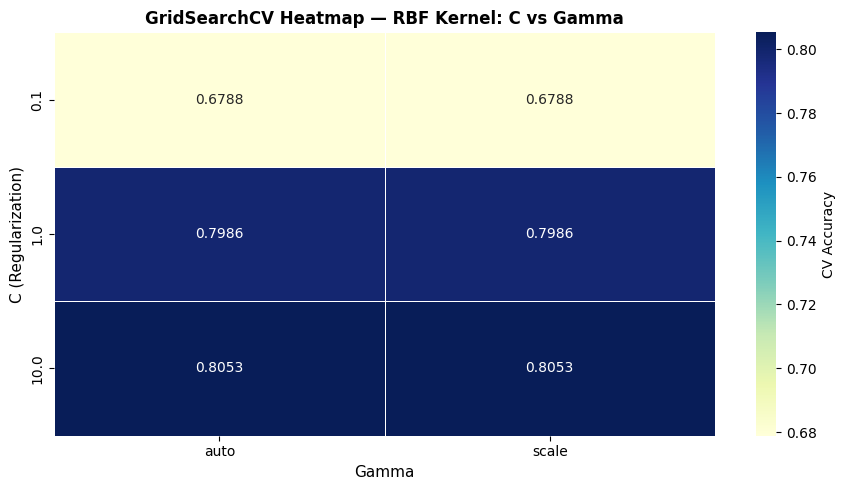

In [ ]:
# ──────────────────────────────────────────────────────────
# 3.3  GridSearch Results — Top 10 & Heatmap
# ──────────────────────────────────────────────────────────
cv_results = pd.DataFrame(gs.cv_results_)
top10 = (cv_results[['params', 'mean_train_score', 'mean_test_score', 'std_test_score']]
         .sort_values('mean_test_score', ascending=False)
         .head(10)
         .reset_index(drop=True))
top10.columns = ['Parameters', 'Train Score', 'Val Score', 'Val Std']
top10.index  += 1
print('Top 10 SVM Configurations:')
print(top10.to_string())

# Heatmap C vs Gamma for RBF
rbf = cv_results[cv_results['param_kernel'] == 'rbf'].copy()
rbf['param_C']     = rbf['param_C'].astype(float)
rbf['param_gamma'] = rbf['param_gamma'].astype(str)
try:
    pivot = rbf.pivot_table(index='param_C', columns='param_gamma',
                            values='mean_test_score', aggfunc='max')
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu',
                linewidths=0.5, ax=ax, cbar_kws={'label': 'CV Accuracy'})
    ax.set_title('GridSearchCV Heatmap — RBF Kernel: C vs Gamma',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Gamma', fontsize=11)
    ax.set_ylabel('C (Regularization)', fontsize=11)
    plt.tight_layout()
    plt.savefig('gridsearch_heatmap.png', dpi=120, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f'Heatmap skipped: {e}')

In [ ]:
# ──────────────────────────────────────────────────────────
# 3.4  Train Final Model with Best Parameters
# ──────────────────────────────────────────────────────────
BEST_SVM_PARAMS = gs.best_params_
print(f'Best SVM parameters: {BEST_SVM_PARAMS}')

best_svm = SVC(**BEST_SVM_PARAMS, random_state=RANDOM_STATE)
t0 = time.time()
best_svm.fit(X_train_scaled, y_train)
print(f'Training done in {time.time()-t0:.2f}s')

y_pred_train = best_svm.predict(X_train_scaled)
y_pred_test  = best_svm.predict(X_test_scaled)
print('Predictions generated for train and test sets.')

Best SVM parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Training done in 7.20s
Predictions generated for train and test sets.


---
## 4. Evaluation

In [ ]:
# ──────────────────────────────────────────────────────────
# 4.1  Performance Metrics — Train & Test
# ──────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, name):
    return {
        'Dataset'              : name,
        'Accuracy'             : accuracy_score(y_true, y_pred),
        'Precision (macro)'    : precision_score(y_true, y_pred, average='macro',    zero_division=0),
        'Recall (macro)'       : recall_score(   y_true, y_pred, average='macro',    zero_division=0),
        'F1-Score (macro)'     : f1_score(        y_true, y_pred, average='macro',    zero_division=0),
        'Precision (weighted)' : precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall (weighted)'    : recall_score(   y_true, y_pred, average='weighted', zero_division=0),
        'F1-Score (weighted)'  : f1_score(        y_true, y_pred, average='weighted', zero_division=0),
    }

m_train = compute_metrics(y_train, y_pred_train, 'Train (80%)')
m_test  = compute_metrics(y_test,  y_pred_test,  'Test  (20%)')

print('=' * 65)
print('   PERFORMANCE METRICS — TRAIN & TEST')
print('=' * 65)
for m in [m_train, m_test]:
    print(f"\n  [{m['Dataset']}]")
    for k, v in m.items():
        if k != 'Dataset':
            print(f'    {k:<25}: {v:.4f}  ({v*100:.2f}%)')
print('=' * 65)

   PERFORMANCE METRICS — TRAIN & TEST

  [Train (80%)]
    Accuracy                 : 1.0000  (100.00%)
    Precision (macro)        : 1.0000  (100.00%)
    Recall (macro)           : 1.0000  (100.00%)
    F1-Score (macro)         : 1.0000  (100.00%)
    Precision (weighted)     : 1.0000  (100.00%)
    Recall (weighted)        : 1.0000  (100.00%)
    F1-Score (weighted)      : 1.0000  (100.00%)

  [Test  (20%)]
    Accuracy                 : 0.8365  (83.65%)
    Precision (macro)        : 0.8421  (84.21%)
    Recall (macro)           : 0.8365  (83.65%)
    F1-Score (macro)         : 0.8346  (83.46%)
    Precision (weighted)     : 0.8421  (84.21%)
    Recall (weighted)        : 0.8365  (83.65%)
    F1-Score (weighted)      : 0.8346  (83.46%)


Text(0.5, 1.0, 'Confusion Matrix 20% Testing')

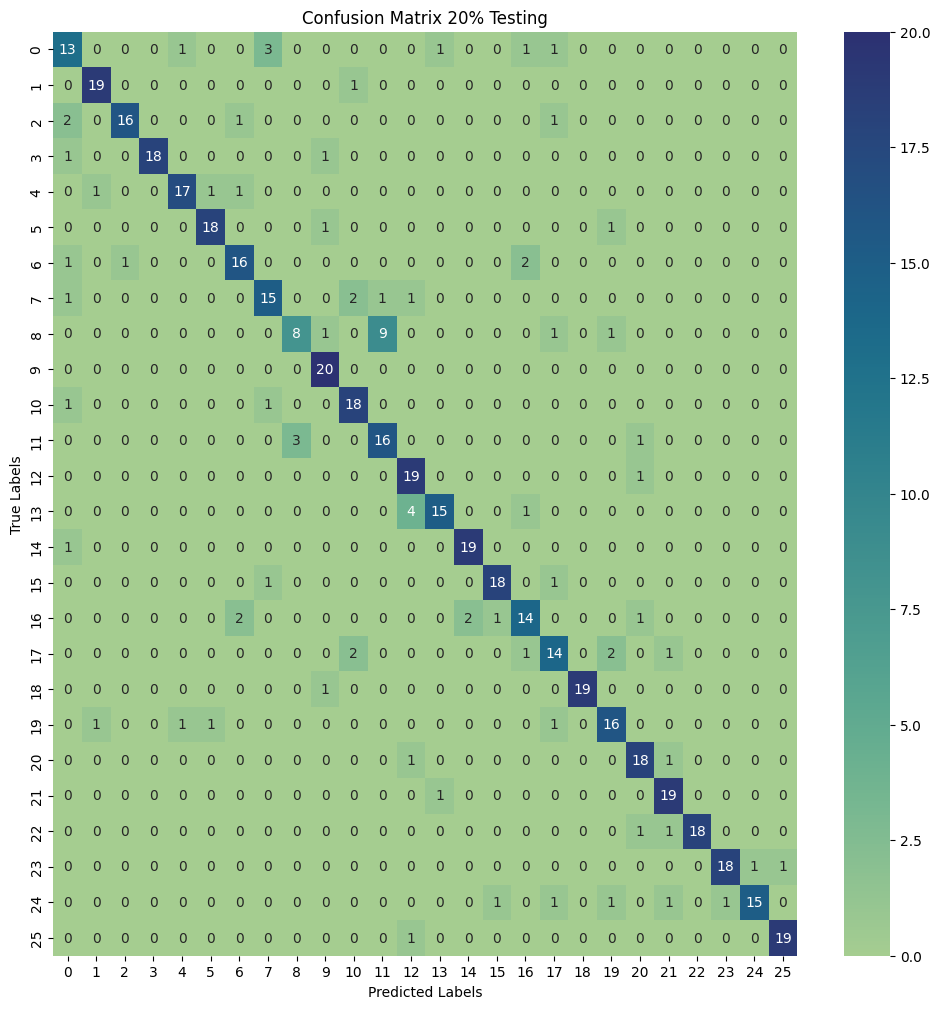

In [ ]:
#Confusion Matrix For Test
plt.figure(figsize=(12, 12))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="crest", xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix 20% Testing")

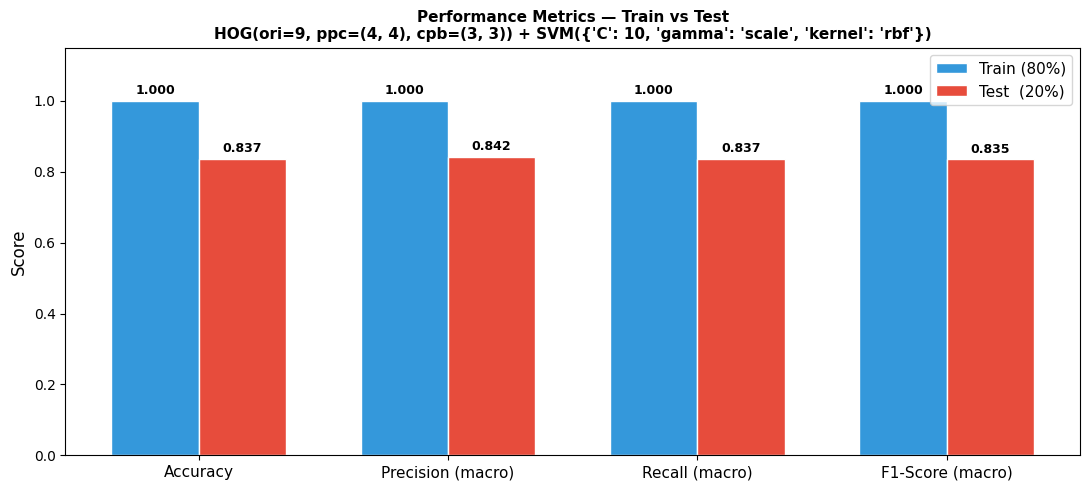

In [ ]:
# ──────────────────────────────────────────────────────────
# 4.2  Metrics Comparison Bar Chart
# ──────────────────────────────────────────────────────────
metrics_list = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)']
tr_vals = [m_train[m] for m in metrics_list]
te_vals = [m_test[m]  for m in metrics_list]

x     = np.arange(len(metrics_list))
width = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width/2, tr_vals, width, label='Train (80%)', color='#3498db', edgecolor='white')
b2 = ax.bar(x + width/2, te_vals, width, label='Test  (20%)', color='#e74c3c', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(metrics_list, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(
    'Performance Metrics — Train vs Test\n'
    f'HOG(ori={BEST_HOG["orientations"]}, ppc={BEST_HOG["pixels_per_cell"]}, '
    f'cpb={BEST_HOG["cells_per_block"]}) + SVM({BEST_SVM_PARAMS})',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=11)
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
summary = pd.DataFrame([
    {'Evaluation': 'Train (80%)',     **{k: f'{v:.4f}' for k, v in m_train.items()  if k != 'Dataset'}},
    {'Evaluation': 'Test  (20%)',     **{k: f'{v:.4f}' for k, v in m_test.items()   if k != 'Dataset'}},
]).set_index('Evaluation')

print('=' * 80)
print('   FINAL EVALUATION')
print('=' * 80)
print(f'  Dataset      : EMNIST Letters  (emnist-letters-train.csv)')
print(f'  Classes      : 26  (A–Z, labels 1–26)')
print(f'  Total samples: {N_TOTAL}  ({N_PER_CLASS}/class, balanced, shuffled)')
print(f'  Train/Test   : 80% / 20%  (stratified split)')
print(f'\n  HOG Parameters:')
for k, v in BEST_HOG.items():
    print(f'    {k:<20} = {v}')
print(f'    {"feature_dim":<20} = {X_train_hog.shape[1]}')
print(f'\n  SVM Parameters (GridSearch best):')
for k, v in BEST_SVM_PARAMS.items():
    print(f'    {k:<10} = {v}')
print(f'\n  Performance Metrics:')
print(summary[['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)']].to_string())
print('=' * 80)

   FINAL EVALUATION
  Dataset      : EMNIST Letters  (emnist-letters-train.csv)
  Classes      : 26  (A–Z, labels 1–26)
  Total samples: 2600  (100/class, balanced, shuffled)
  Train/Test   : 80% / 20%  (stratified split)

  HOG Parameters:
    orientations         = 9
    pixels_per_cell      = (4, 4)
    cells_per_block      = (3, 3)
    transform_sqrt       = True
    block_norm           = L2-Hys
    feature_dim          = 2025

  SVM Parameters (GridSearch best):
    C          = 10
    gamma      = scale
    kernel     = rbf

  Performance Metrics:
            Accuracy Precision (macro) Recall (macro) F1-Score (macro)
Evaluation                                                            
Train (80%)   1.0000            1.0000         1.0000           1.0000
Test  (20%)   0.8365            0.8421         0.8365           0.8346
